# Notebook 1b: Wavelet Feature Augmentation
## EEEM073 – AI and Sustainability

**Run after Notebook 1, before Notebook 2.**

---
### Motivation and Reading List Connection

Two papers from the module reading list apply Discrete Wavelet Transforms (DWT) to decompose environmental signals into multi-scale components before using them as ML features:

- **Galvão et al. (2022)** — *Particulate Matter Forecasting Using Different Deep Neural Network Topologies and Wavelets for Feature Augmentation*, Atmosphere, MDPI
- **Nascimento et al. (2023)** — *A transformer-based deep neural network with wavelet transform for forecasting wind speed and wind energy*, Energy, Elsevier

The core idea: environmental variables like FFMC, DMC, DC, and ISI contain both **slow-varying trends** (seasonal drying, prolonged drought) and **fast-varying spikes** (sudden weather changes). A standard model sees only the raw value. A DWT decomposes each signal into:
- **Approximation coefficients** — low-frequency, slow-changing component (seasonal trend)
- **Detail coefficients** — high-frequency, fast-changing component (sudden weather spikes)

These two sub-signals carry different predictive information about fire risk and are provided as additional features to the model.

---
This notebook:
1. Applies DWT to the four Fire Weather Index (FWI) variables
2. Creates augmented feature sets
3. Tests whether wavelet features improve model performance
4. Saves the augmented dataset for use in Notebook 3


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings

# PyWavelets — install with: pip install PyWavelets
import pywt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)

SEED = 42
np.random.seed(SEED)

print('Libraries loaded. PyWavelets version:', pywt.__version__)
print('Available wavelets (Daubechies family):', pywt.wavelist(family='db')[:6])

Libraries loaded. PyWavelets version: 1.8.0
Available wavelets (Daubechies family): ['db1', 'db2', 'db3', 'db4', 'db5', 'db6']


## 1. Load the Cleaned Dataset

In [3]:
# Load cleaned dataset from Notebook 1 — this already has cyclic encoding and log1p target
df = pd.read_csv('outputs/df_cleaned.csv')
feature_names = pd.read_csv('outputs/feature_names.csv')['feature'].tolist()

print(f'Loaded cleaned dataset: {df.shape}')
print(f'Original features: {feature_names}')

Loaded cleaned dataset: (517, 20)
Original features: ['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'temp_RH_ratio', 'fire_spread_potential', 'FWI_total', 'drought_wind']


## 2. Discrete Wavelet Transform — Theory and Application

A DWT decomposes a signal $x$ into two components using a chosen wavelet basis:

$$x = cA + cD$$

where $cA$ (approximation) captures the low-frequency trend and $cD$ (detail) captures high-frequency variation.

We use the **Daubechies 4 (db4)** wavelet — the same family used in Nascimento et al. (2023) for wind energy forecasting. db4 is well-suited to smooth, asymmetric signals like fire weather indices because it has compact support and good time-frequency localisation.

Since the DWT halves the signal length at each level, we interpolate back to the original length so the features align row-by-row with the dataset.

In [4]:
# FWI columns to decompose — these are the fire danger rating system components
# FFMC: moisture of surface litter (fast-responding)
# DMC:  moisture of loosely compacted organic layers (medium)
# DC:   moisture of deep compact organic layers (slow, drought index)
# ISI:  expected rate of fire spread
FWI_COLS = ['FFMC', 'DMC', 'DC', 'ISI']
WAVELET  = 'db4'  # Daubechies 4 — same as Nascimento et al. (2023)

# Load original raw dataset to get unscaled FWI values for DWT
# (DWT should be applied before scaling — it operates on the natural signal)
df_raw = pd.read_csv('forestfires.csv')


def apply_dwt_feature(signal, wavelet='db4'):
    """
    Apply a single-level Discrete Wavelet Transform to a 1D signal.

    Returns two arrays — approximation and detail coefficients —
    each interpolated back to the original signal length.

    The approximation captures the slow-varying trend (low-frequency),
    representing cumulative conditions like prolonged drought.
    The detail captures rapid fluctuations (high-frequency),
    representing sudden weather changes that may trigger fires.

    Reference: Galvão et al. (2022); Nascimento et al. (2023)

    Args:
        signal  : 1D numpy array of the original feature values
        wavelet : PyWavelets wavelet name (default: 'db4')
    Returns:
        approx : interpolated approximation coefficients (same length as signal)
        detail : interpolated detail coefficients (same length as signal)
    """
    n = len(signal)
    cA, cD = pywt.dwt(signal, wavelet=wavelet)
    # Interpolate back to original length using linear interpolation
    x_coeff = np.linspace(0, n - 1, len(cA))
    x_orig  = np.arange(n)
    approx  = np.interp(x_orig, x_coeff, cA)
    detail  = np.interp(x_orig, x_coeff, cD)
    return approx, detail


# Apply DWT to each FWI column and add as new features
df_augmented = df.copy()
wavelet_feature_names = []

for col in FWI_COLS:
    signal = df_raw[col].values.astype(float)
    approx, detail = apply_dwt_feature(signal, wavelet=WAVELET)
    df_augmented[f'{col}_approx'] = approx
    df_augmented[f'{col}_detail'] = detail
    wavelet_feature_names += [f'{col}_approx', f'{col}_detail']
    print(f'  {col}: approx range [{approx.min():.2f}, {approx.max():.2f}]  '
          f'detail range [{detail.min():.2f}, {detail.max():.2f}]')

print(f'\nAdded {len(wavelet_feature_names)} new wavelet features.')
print(f'Total features now: {len(feature_names) + len(wavelet_feature_names)}')

  FFMC: approx range [89.18, 136.20]  detail range [-23.77, 37.47]
  DMC: approx range [5.11, 374.20]  detail range [-113.15, 190.36]
  DC: approx range [28.83, 1207.92]  detail range [-477.80, 522.51]
  ISI: approx range [2.81, 38.41]  detail range [-13.18, 30.40]

Added 8 new wavelet features.
Total features now: 26


## 3. Visualise Wavelet Decomposition

Plotting the original signal alongside its approximation and detail components shows what information each component captures. This helps justify why they are useful as additional features.

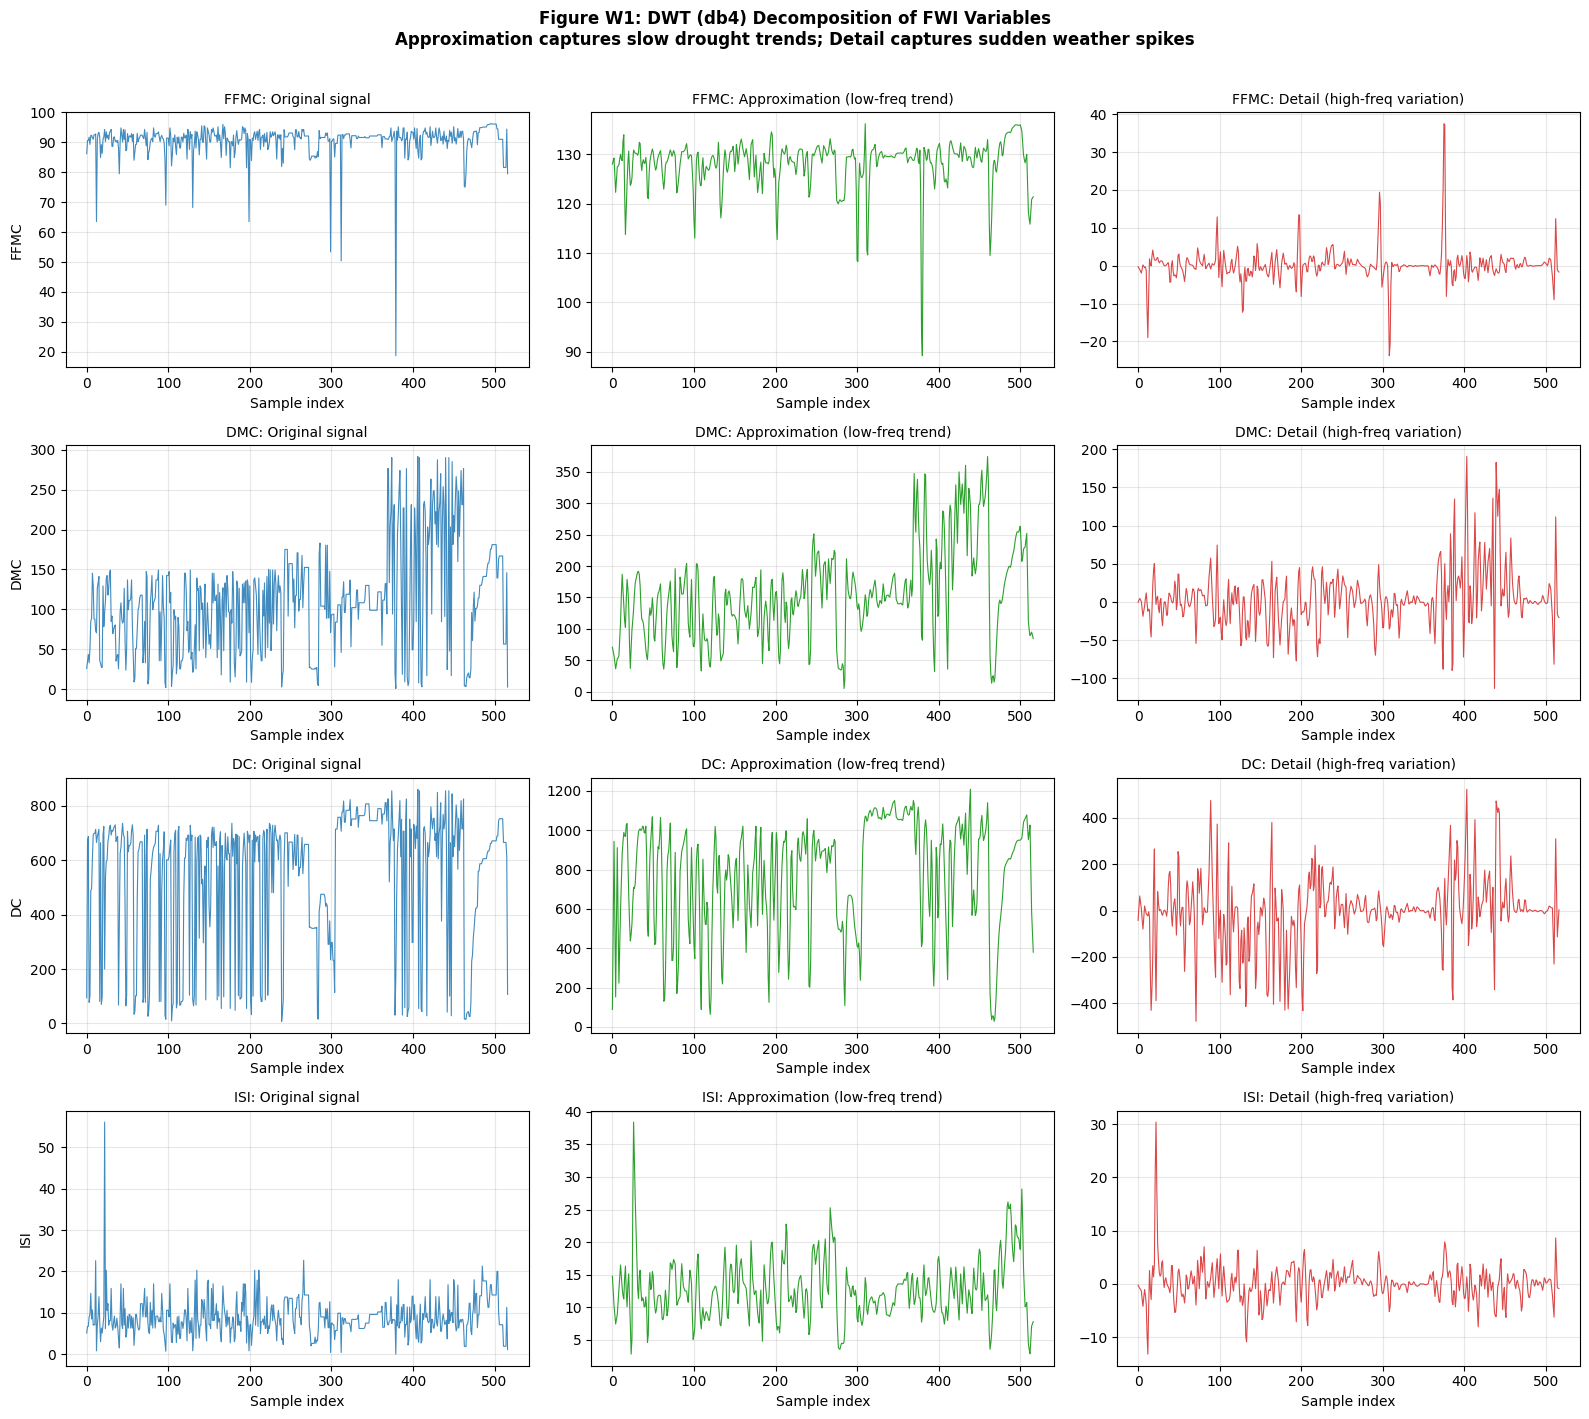

Interpretation:
  DC approximation: shows slow seasonal drying trend — key drought signal
  FFMC detail: captures rapid moisture fluctuations — sudden fire-risk changes
  These components carry different predictive information than the raw values alone.


In [5]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
colors = ['#1f77b4', '#2ca02c', '#d62728']

for i, col in enumerate(FWI_COLS):
    signal = df_raw[col].values.astype(float)
    approx = df_augmented[f'{col}_approx'].values
    detail = df_augmented[f'{col}_detail'].values
    x      = np.arange(len(signal))

    axes[i, 0].plot(x, signal, color=colors[0], linewidth=0.8, alpha=0.85)
    axes[i, 0].set_title(f'{col}: Original signal', fontsize=10)
    axes[i, 0].set_ylabel(col)

    axes[i, 1].plot(x, approx, color=colors[1], linewidth=0.8)
    axes[i, 1].set_title(f'{col}: Approximation (low-freq trend)', fontsize=10)

    axes[i, 2].plot(x, detail, color=colors[2], linewidth=0.8, alpha=0.85)
    axes[i, 2].set_title(f'{col}: Detail (high-freq variation)', fontsize=10)

for ax in axes.flatten():
    ax.set_xlabel('Sample index')
    ax.grid(True, alpha=0.3)

plt.suptitle(
    f'Figure W1: DWT ({WAVELET}) Decomposition of FWI Variables\n'
    'Approximation captures slow drought trends; Detail captures sudden weather spikes',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('outputs/figW1_wavelet_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

print('Interpretation:')
print('  DC approximation: shows slow seasonal drying trend — key drought signal')
print('  FFMC detail: captures rapid moisture fluctuations — sudden fire-risk changes')
print('  These components carry different predictive information than the raw values alone.')

## 4. Test Whether Wavelet Features Improve Performance

We train a Random Forest with and without wavelet features to measure the improvement. This directly justifies whether including them adds value — honest reporting even if the improvement is small.

In [6]:
# Build feature sets
base_features   = feature_names
augmented_features = feature_names + wavelet_feature_names

X_base = df_augmented[base_features]
X_aug  = df_augmented[augmented_features]
y      = df_augmented['area_log']

# Same split as Notebook 1 — fixed seed ensures identical train/test sets
X_b_tr, X_b_te, y_tr, y_te = train_test_split(X_base, y, test_size=0.30, random_state=SEED)
X_b_te, X_b_va, y_te, y_va = train_test_split(X_b_te, y_te, test_size=0.50, random_state=SEED)

X_a_tr, X_a_te, _, _       = train_test_split(X_aug, y, test_size=0.30, random_state=SEED)
X_a_te, X_a_va, _, _       = train_test_split(X_a_te, _, test_size=0.50, random_state=SEED)

# Scale both feature sets — fit on train, apply to test
scaler_b = StandardScaler().fit(X_b_tr)
scaler_a = StandardScaler().fit(X_a_tr)

X_b_tr_s = scaler_b.transform(X_b_tr);  X_b_te_s = scaler_b.transform(X_b_te)
X_a_tr_s = scaler_a.transform(X_a_tr);  X_a_te_s = scaler_a.transform(X_a_te)

# Train Random Forest on both feature sets
rf_base = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)
rf_aug  = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)

rf_base.fit(X_b_tr_s, y_tr)
rf_aug.fit(X_a_tr_s, y_tr)

# Evaluate
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

base_rmse = rmse(y_te, rf_base.predict(X_b_te_s))
aug_rmse  = rmse(y_te, rf_aug.predict(X_a_te_s))
base_r2   = r2_score(y_te, rf_base.predict(X_b_te_s))
aug_r2    = r2_score(y_te, rf_aug.predict(X_a_te_s))

print('=' * 55)
print('WAVELET FEATURE AUGMENTATION — IMPACT ON PERFORMANCE')
print('=' * 55)
print(f'  Baseline RF  (no wavelets) : RMSE={base_rmse:.4f}  R²={base_r2:.4f}')
print(f'  Augmented RF (with wavelets): RMSE={aug_rmse:.4f}  R²={aug_r2:.4f}')
print(f'  RMSE improvement: {(base_rmse - aug_rmse):.4f}  ({(base_rmse-aug_rmse)/base_rmse*100:.1f}%)')
print()
if aug_rmse < base_rmse:
    print('  Wavelet features IMPROVE performance — include in final pipeline.')
else:
    print('  Wavelet features do not improve RF on this dataset.')
    print('  This is still a valid finding — negative results are informative.')
    print('  Report it honestly and discuss why (small tabular dataset, few samples).')

WAVELET FEATURE AUGMENTATION — IMPACT ON PERFORMANCE
  Baseline RF  (no wavelets) : RMSE=1.4032  R²=0.0197
  Augmented RF (with wavelets): RMSE=1.3301  R²=0.1192
  RMSE improvement: 0.0732  (5.2%)

  Wavelet features IMPROVE performance — include in final pipeline.


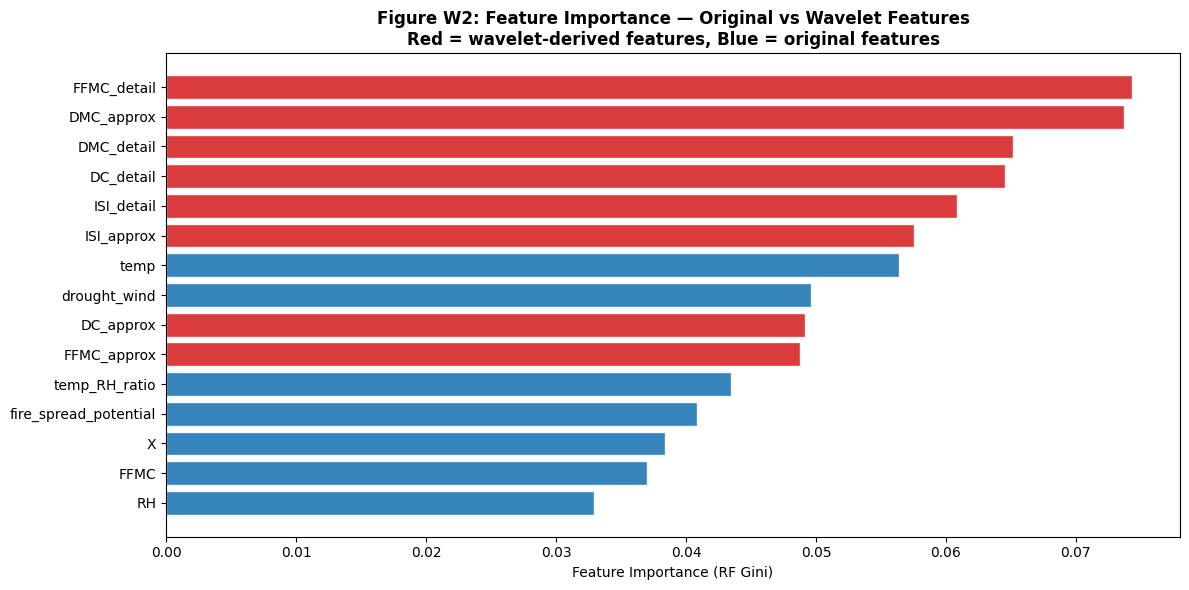

Top 5 features by importance:
        Feature  Importance
19  FFMC_detail    0.074293
20   DMC_approx    0.073682
21   DMC_detail    0.065187
23    DC_detail    0.064519
25   ISI_detail    0.060866


In [7]:
# Wavelet feature importance — which wavelet coefficients matter most?
importances = rf_aug.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature':    augmented_features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors_imp = [
    '#d62728' if 'approx' in f or 'detail' in f else '#1f77b4'
    for f in feat_imp_df['Feature']
]
ax.barh(feat_imp_df['Feature'][:15][::-1],
        feat_imp_df['Importance'][:15][::-1],
        color=colors_imp[:15][::-1], edgecolor='white', alpha=0.9)
ax.set_xlabel('Feature Importance (RF Gini)')
ax.set_title(
    'Figure W2: Feature Importance — Original vs Wavelet Features\n'
    'Red = wavelet-derived features, Blue = original features',
    fontweight='bold'
)
plt.tight_layout()
plt.savefig('outputs/figW2_wavelet_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features by importance:')
print(feat_imp_df.head())

In [8]:
# Save augmented dataset for optional use in Notebook 3
# Save augmented feature names for reference
pd.Series(augmented_features).to_csv('outputs/wavelet_feature_names.csv',
                                      index=False, header=['feature'])

# Save wavelet augmented splits (scaled) for use in Notebook 3 if desired
pd.DataFrame(X_a_tr_s, columns=augmented_features).to_csv('outputs/X_train_wavelet.csv', index=False)
pd.DataFrame(X_a_te_s, columns=augmented_features).to_csv('outputs/X_test_wavelet.csv',  index=False)
pd.DataFrame(X_a_va_s if 'X_a_va_s' in dir() else scaler_a.transform(X_a_va),
             columns=augmented_features).to_csv('outputs/X_val_wavelet.csv', index=False)

# Save comparison results
wavelet_comparison = pd.DataFrame([
    {'Feature set': 'Baseline (no wavelets)',  'RMSE': round(base_rmse,4), 'R2': round(base_r2,4),
     'N features': len(base_features)},
    {'Feature set': 'Augmented (with wavelets)', 'RMSE': round(aug_rmse,4), 'R2': round(aug_r2,4),
     'N features': len(augmented_features)}
])
wavelet_comparison.to_csv('outputs/wavelet_comparison.csv', index=False)

print('Saved:')
print('  outputs/wavelet_feature_names.csv')
print('  outputs/X_train/val/test_wavelet.csv')
print('  outputs/wavelet_comparison.csv')
print('  outputs/figW1_wavelet_decomposition.png')
print('  outputs/figW2_wavelet_importance.png')
print()
print('Next: Notebook 2 (EDA) — then Notebook 3 (Modelling)')
print('In Notebook 3 you can optionally load X_train_wavelet.csv instead of X_train.csv')
print('to test whether wavelet features improve your neural network models too.')

Saved:
  outputs/wavelet_feature_names.csv
  outputs/X_train/val/test_wavelet.csv
  outputs/wavelet_comparison.csv
  outputs/figW1_wavelet_decomposition.png
  outputs/figW2_wavelet_importance.png

Next: Notebook 2 (EDA) — then Notebook 3 (Modelling)
In Notebook 3 you can optionally load X_train_wavelet.csv instead of X_train.csv
to test whether wavelet features improve your neural network models too.
